<a id="Frequency-curves-and-tail-distributions"></a>
# Frequency curves and tail distributions

short tutorial about frequency curves and fitting a tail distribution

### Example 1: Tropical cyclone impacts in Haiti

In [23]:
from climada.entity import ImpactFunc, ImpactFuncSet, ImpfTropCyclone
from climada.util.api_client import Client
from climada.engine import ImpactCalc
import matplotlib.pyplot as plt
import numpy as np

client = Client()

impf_set = ImpactFuncSet([ImpfTropCyclone.from_emanuel_usa()])

exp = client.get_litpop(country="Haiti")

haz = client.get_hazard(
    "tropical_cyclone",
    properties={
        "country_name": "Haiti",
        "climate_scenario": "historical",
        "nb_synth_tracks": "10",
    },
)

impact = ImpactCalc(exp, impf_set, haz).impact()

2026-05-06 15:32:02,162 - climada.entity.exposures.base - INFO - Reading /Users/vgebhart/climada/data/exposures/litpop/LitPop_150arcsec_HTI/v3/LitPop_150arcsec_HTI.hdf5
2026-05-06 15:32:07,338 - climada.hazard.io - INFO - Reading /Users/vgebhart/climada/data/hazard/tropical_cyclone/tropical_cyclone_10synth_tracks_150arcsec_HTI_1980_2020/v2/tropical_cyclone_10synth_tracks_150arcsec_HTI_1980_2020.hdf5
2026-05-06 15:32:07,366 - climada.entity.exposures.base - INFO - No specific impact function column found for hazard TC. Using the anonymous 'impf_' column.
2026-05-06 15:32:07,367 - climada.entity.exposures.base - INFO - Matching 1329 exposures with 1332 centroids.
2026-05-06 15:32:07,370 - climada.util.coordinates - INFO - No exact centroid match found. Reprojecting coordinates to nearest neighbor closer than the threshold = 0.08333333333331439 degree
2026-05-06 15:32:07,372 - climada.engine.impact_calc - INFO - Calculating impact for 1329 assets (>0) and 43560 events.


Standard frequency curve based to the impact data points

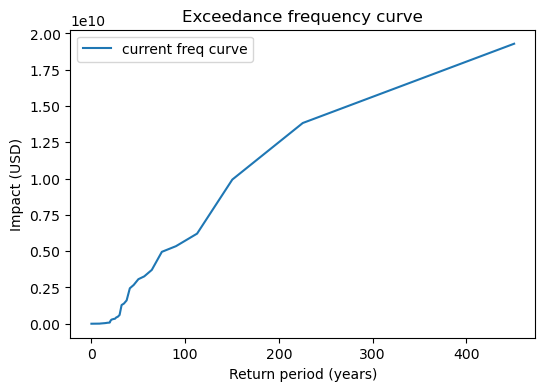

In [4]:
freq_curve = impact.calc_freq_curve()
_, ax = plt.subplots(1, 1, figsize=(6, 4))
freq_curve.plot(axis=ax, label="current freq curve")
ax.legend();

Extrapolation options

2026-05-06 15:27:09,624 - climada.util.interpolation - INFO - Fitted GPD parameters using 14 points: xi=0.223, beta=5.08e+09.
2026-05-06 15:27:09,625 - climada.util.interpolation - INFO - GOF metrics: RMSE_log=0.117, KS=0.101
2026-05-06 15:27:09,627 - climada.util.interpolation - INFO - Fitted GPD parameters using 10 points: xi=0.278, beta=5.22e+09.
2026-05-06 15:27:09,627 - climada.util.interpolation - INFO - GOF metrics: RMSE_log=0.122, KS=0.125
2026-05-06 15:27:09,629 - climada.util.interpolation - INFO - Fitted GPD parameters using 21 points: xi=0.117, beta=4.83e+09.
2026-05-06 15:27:09,629 - climada.util.interpolation - INFO - GOF metrics: RMSE_log=0.262, KS=0.213


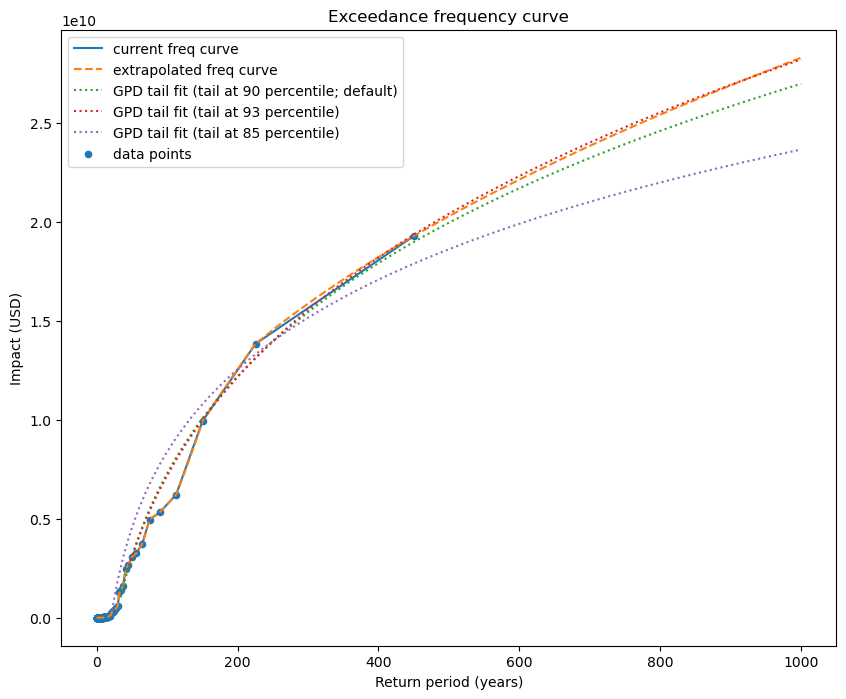

In [21]:
return_periods = np.linspace(0, 1000, 500)
freq_curve_extrapolated = freq_curve.interpolate(
    return_periods=return_periods, method="extrapolate"
)
freq_curve_fit_GPD = freq_curve.interpolate(
    return_periods=return_periods, method="fit_GPD", min_sample_size=10
)
freq_curve_fit_GPD_93 = freq_curve.interpolate(
    return_periods=return_periods,
    method="fit_GPD",
    min_sample_size=10,
    threshold_percentile=93,
)
freq_curve_fit_GPD_85 = freq_curve.interpolate(
    return_periods=return_periods,
    method="fit_GPD",
    min_sample_size=10,
    threshold_percentile=85,
)


fig, ax = plt.subplots(1, 1, figsize=(10, 8))
freq_curve.plot(axis=ax, label="current freq curve")
freq_curve_extrapolated.plot(axis=ax, label="extrapolated freq curve", linestyle="--")
freq_curve_fit_GPD.plot(
    axis=ax, label="GPD tail fit (tail at 90 percentile; default)", linestyle=":"
)
freq_curve_fit_GPD_93.plot(
    axis=ax, label="GPD tail fit (tail at 93 percentile)", linestyle=":"
)
freq_curve_fit_GPD_85.plot(
    axis=ax, label="GPD tail fit (tail at 85 percentile)", linestyle=":"
)
ax.scatter(freq_curve.return_per, freq_curve.impact, label="data points", s=20)
ax.legend();

### Example 2: River floods in Italy


In [ ]:
client = Client()

exp_ita = client.get_litpop(country="Italy")

rf = client.get_hazard(
    "river_flood",
    properties={
        "country_name": "Italy",
        "climate_scenario": "historical",
    },
)

impf = ImpactFunc()
# based on iaimip test runs in MATLAB, ca 2017, with impact function 20160929, a dummy FL damage function, a copy of TS
impf.intensity = np.array(
    [0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5, 5.5, 6, 6.5, 7, 7.5, 8, 10, 16]
)
impf.mdd = np.array(
    [
        0,
        0.01,
        0.02,
        0.05,
        0.1,
        0.2,
        0.3,
        0.4,
        0.5,
        0.6,
        0.65,
        0.675,
        0.7,
        0.71,
        0.72,
        0.725,
        0.725,
        0.725,
        0.725,
    ]
)
impf.paa = np.array(
    [
        0,
        0.39346934,
        0.632120559,
        0.77686984,
        0.864664717,
        0.917915001,
        0.950212932,
        0.969802617,
        0.981684361,
        0.988891003,
        0.993262053,
        0.995913229,
        0.997521248,
        0.998496561,
        0.999088118,
        0.999446916,
        0.999664537,
        0.9999546,
        0.999999887,
    ]
)
impf.haz_type = "RF"
impf.intensity_unit = "m"
impf.id = 1
impf_set_rf = ImpactFuncSet([impf])

impact_ita = ImpactCalc(exp_ita, impf_set_rf, rf).impact()

2026-05-06 15:36:25,998 - climada.entity.exposures.base - INFO - Reading /Users/vgebhart/climada/data/exposures/litpop/LitPop_150arcsec_ITA/v3/LitPop_150arcsec_ITA.hdf5
2026-05-06 15:36:31,461 - climada.hazard.io - INFO - Reading /Users/vgebhart/climada/data/hazard/river_flood/river_flood_150arcsec_hist_ITA_1980_2000/v2/river_flood_150arcsec_hist_ITA_1980_2000.hdf5
2026-05-06 15:36:31,480 - climada.entity.exposures.base - INFO - No specific impact function column found for hazard RF. Using the anonymous 'impf_' column.
2026-05-06 15:36:31,481 - climada.entity.exposures.base - INFO - Matching 19124 exposures with 19093 centroids.
2026-05-06 15:36:31,508 - climada.util.coordinates - INFO - No exact centroid match found. Reprojecting coordinates to nearest neighbor closer than the threshold = 0.08333333333331439 degree
2026-05-06 15:36:31,521 - climada.util.coordinates - WARNING - Distance to closest centroid is greater than 0.083333 degree for 3 coordinates.
2026-05-06 15:36:31,523 - cli

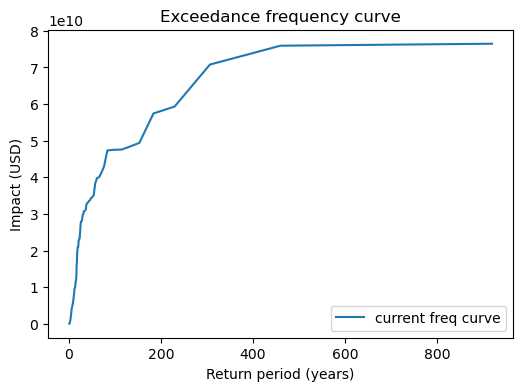

In [4]:
freq_curve_ita = impact_ita.calc_freq_curve()
_, ax = plt.subplots(1, 1, figsize=(6, 4))
freq_curve_ita.plot(axis=ax, label="current freq curve")
ax.legend();

Extrapolation options

2026-05-06 15:39:14,028 - climada.util.interpolation - INFO - Fitted GPD parameters using 92 points: xi=0.1, beta=1.62e+10.
2026-05-06 15:39:14,028 - climada.util.interpolation - INFO - GOF metrics: RMSE_log=0.167, KS=0.1
2026-05-06 15:39:14,030 - climada.util.interpolation - INFO - Fitted GPD parameters using 46 points: xi=0.128, beta=1.38e+10.
2026-05-06 15:39:14,031 - climada.util.interpolation - INFO - GOF metrics: RMSE_log=0.155, KS=0.144
2026-05-06 15:39:14,033 - climada.util.interpolation - INFO - Fitted GPD parameters using 19 points: xi=0.262, beta=1.28e+10.
2026-05-06 15:39:14,033 - climada.util.interpolation - INFO - GOF metrics: RMSE_log=0.207, KS=0.176


/Users/vgebhart/gitprojects/climada_repo/climada_python/climada/engine/impact.py:2382: RuntimeWarning: divide by zero encountered in divide
  exceedance_frequency = 1 / np.array(return_periods)
/Users/vgebhart/gitprojects/climada_repo/climada_python/climada/util/interpolation.py:419: RuntimeWarning: invalid value encountered in power
  return lambda_u * (1 + xi * (values - threshold) / beta) ** (-1 / xi)
/Users/vgebhart/gitprojects/climada_repo/climada_python/climada/util/interpolation.py:513: RuntimeWarning: invalid value encountered in log
  return np.sum((np.log(ex_freq) - np.log(model)) ** 2)


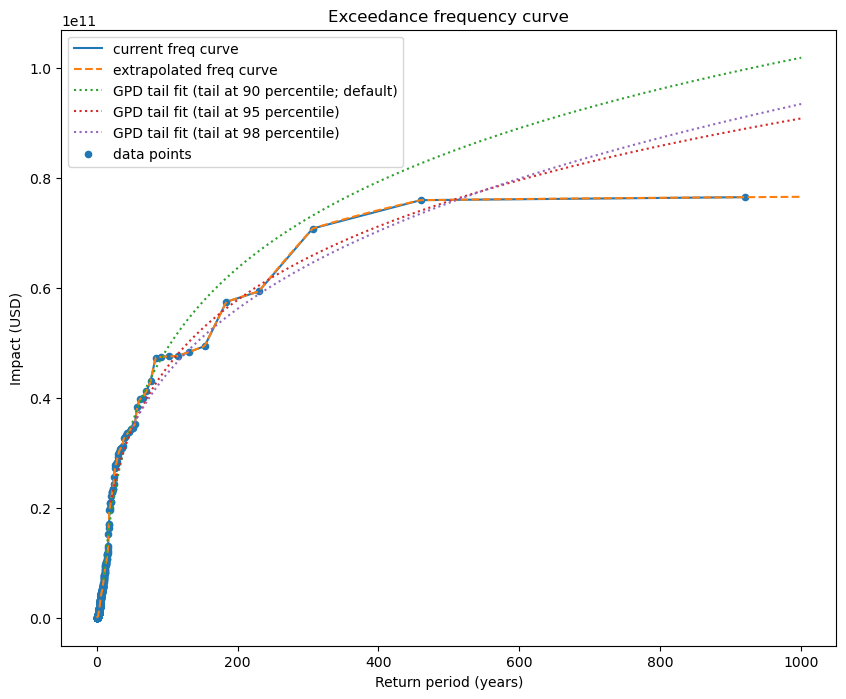

In [8]:
return_periods_ita = np.linspace(0, 1000, 500)
freq_curve_extrapolated_ita = freq_curve_ita.interpolate(
    return_periods=return_periods_ita, method="extrapolate"
)
freq_curve_fit_GPD_ita = freq_curve_ita.interpolate(
    return_periods=return_periods_ita, method="fit_GPD", min_sample_size=10
)
freq_curve_fit_GPD_ita_95 = freq_curve_ita.interpolate(
    return_periods=return_periods_ita,
    method="fit_GPD",
    min_sample_size=10,
    threshold_percentile=95,
)
freq_curve_fit_GPD_ita_98 = freq_curve_ita.interpolate(
    return_periods=return_periods_ita,
    method="fit_GPD",
    min_sample_size=10,
    threshold_percentile=98,
)


fig, ax = plt.subplots(1, 1, figsize=(10, 8))
freq_curve_ita.plot(axis=ax, label="current freq curve")
freq_curve_extrapolated_ita.plot(
    axis=ax, label="extrapolated freq curve", linestyle="--"
)
freq_curve_fit_GPD_ita.plot(
    axis=ax, label="GPD tail fit (tail at 90 percentile; default)", linestyle=":"
)
freq_curve_fit_GPD_ita_95.plot(
    axis=ax, label="GPD tail fit (tail at 95 percentile)", linestyle=":"
)
freq_curve_fit_GPD_ita_98.plot(
    axis=ax, label="GPD tail fit (tail at 98 percentile)", linestyle=":"
)
ax.scatter(freq_curve_ita.return_per, freq_curve_ita.impact, label="data points", s=20)
ax.legend();